In [ ]:
%cd ../../

/Users/hoangle/Projects/untangling-people/ylva/fwo_models


In [2]:
import datetime

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import numpy as np
import holidays
from darts import TimeSeries
from pytorch_lightning.callbacks import TQDMProgressBar
from lightning.pytorch.loggers import TensorBoardLogger
from darts import metrics
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
from darts.models import CatBoostModel, TFTModel, TransformerModel, TSMixerModel, RNNModel, XGBModel, LightGBMModel, NBEATSModel
from darts.dataprocessing.transformers import Scaler, BoxCox, Diff
from sklearn.preprocessing import MinMaxScaler

In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

# Load data and dims

## Load and process data

In [4]:
EPS = 1e-6

In [5]:
path =  "data/processed/pos_daily_snapshot.parquet"
pos_daily_snapshot = pl.read_parquet(path)

pos_daily_snapshot.head()

id,restaurant,date,pcs,src
u32,i64,date,i64,list[str]
0,3,2024-05-30,79,"[""Sold lunches""]"
1,3,2024-09-24,260,"[""Sold lunches Kumpula 9-10 2024""]"
2,3,2025-03-21,120,"[""Physicum lounaat ja hiilijalanjäljet 01112024-31032025""]"
3,1,2024-12-19,661,"[""Chemicum lounaat ja hiilijalanjäljet 01112024-31032025""]"
4,1,2024-09-18,959,"[""Sold lunches Kumpula 9-10 2024""]"


In [6]:
path = "data/processed/dim_restaurants.xlsx"
dim_restaurants = pl.read_excel(path)

dim_restaurants.head()

restaurant_id,restaurant,restaurant_short
i64,str,str
1,"""600 Chemicum""","""che"""
2,"""620 Exactum""","""exa"""
3,"""610 Physicum""","""phy"""
4,"""570 Viikuna""","""vik"""


In [7]:
pos_daily_snapshot = (
    pos_daily_snapshot

    # Translate to restaurant name from restaurant id
    .join(dim_restaurants, left_on='restaurant', right_on='restaurant_id')
    .drop('restaurant_right', 'restaurant')
    .rename({'restaurant_short': 'restaurant'})


    # Pivot
    .pivot(index='date', on='restaurant', values='pcs')
    .sort('date')
)

pos_daily_snapshot.head()

date,phy,che,exa,vik
date,i64,i64,i64,i64
2023-01-02,null,348,null,null
2023-01-03,null,394,null,null
2023-01-04,null,428,null,null
2023-01-05,null,501,null,null
2023-01-09,33,578,99,280


<Axes: xlabel='date'>

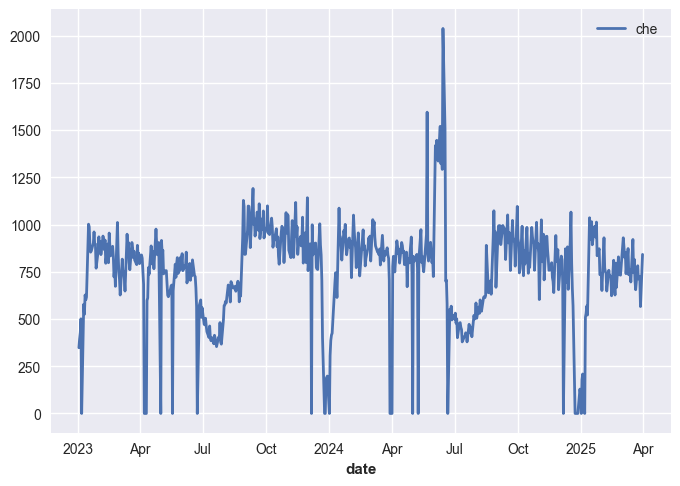

In [8]:
restaurant = "che"

series = (
    TimeSeries
    .from_dataframe(
        pos_daily_snapshot.to_pandas(),
        time_col='date',
        value_cols=[
            restaurant
            # 'che',
            # 'exa',
            # 'phy',
            # 'vik'
        ],
        fillna_value=EPS,
        freq='B',
    )
)

series.plot()

In [9]:
# static_covs_multi = pd.DataFrame(data={"restaurant": [0, 1, 2, 3]})
# series = series.with_static_covariates(static_covs_multi)
# series.static_covariates

## Load dims

### `dim_exam`

In [10]:
dim_exam = (
    pl
    .from_records([
        {'date_begin': '2023-03-06', 'date_end': '2023-03-12'},  
        {'date_begin': '2023-05-01', 'date_end': '2023-05-07'},
        {'date_begin': '2023-10-23', 'date_end': '2023-10-29'},
        {'date_begin': '2023-12-18', 'date_end': '2023-12-24'},
        {'date_begin': '2024-03-04', 'date_end': '2024-03-10'},
        {'date_begin': '2024-05-06', 'date_end': '2024-05-12'},
        {'date_begin': '2024-10-21', 'date_end': '2024-10-27'},
        {'date_begin': '2025-03-03', 'date_end': '2025-03-09'},
    ])
    .with_columns(
        pl.col('date_begin').str.to_date(),
        pl.col('date_end').str.to_date(),
    )
)

dim_exam.head()

date_begin,date_end
date,date
2023-03-06,2023-03-12
2023-05-01,2023-05-07
2023-10-23,2023-10-29
2023-12-18,2023-12-24
2024-03-04,2024-03-10


In [11]:
df = (
    pl.DataFrame()

    # Create blank dataframe with date
    .with_columns(
        pl.date_range(series.time_index.min(), series.time_index.max(), '1d').alias('date')
    )
)

entries_exam = (
    df
    .join(dim_exam, how='cross')
    .filter(
        (pl.col('date') >= pl.col('date_begin'))
        & (pl.col('date') <= pl.col('date_end'))
    )
    .select(
        'date',
        pl.lit(1).alias('exam')
    )
)
cov_exam = (
    df
    .join(entries_exam, on='date', how='left')
    .with_columns(
        pl
        .col('exam')
        .fill_null(0)
        .cast(pl.String())
        .cast(pl.Categorical())
    )

    # Remove non-business days
    .filter(pl.col('date').dt.weekday() < 6)
)


cov_exam.head()

date,exam
date,cat
2023-01-02,"""0"""
2023-01-03,"""0"""
2023-01-04,"""0"""
2023-01-05,"""0"""
2023-01-06,"""0"""


<Axes: xlabel='date'>

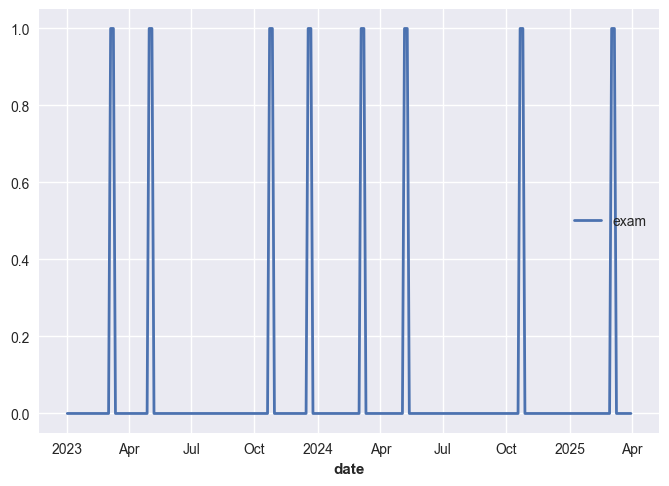

In [12]:
series_exam = (
    TimeSeries
    .from_dataframe(
        df=cov_exam.to_pandas(),
        time_col='date',
        freq='b',
        fill_missing_dates = False,
        value_cols='exam'
    )
    # .astype(np.float32)
)
series_exam.plot()

### `dim_holiday`

In [13]:
fin_holidays = holidays.Finland(years=[2023, 2024, 2025])
dim_holiday = pl.from_records([
    {'date': d, 'name_holiday': n}
    for d, n in fin_holidays.items()
])

dim_holiday.head()

date,name_holiday
date,str
2024-01-01,"""Uudenvuodenpäivä"""
2024-01-06,"""Loppiainen"""
2024-03-29,"""Pitkäperjantai"""
2024-03-31,"""Pääsiäispäivä"""
2024-04-01,"""Toinen pääsiäispäivä"""


In [14]:
cov_holiday = (
    pl.DataFrame()

    # Create blank dataframe with date
    .with_columns(
        pl.date_range(series.time_index.min(), series.time_index.max(), '1d').alias('date')
    )


    # Add dim holiday
    .join(dim_holiday, on='date', how='left')
    .with_columns(pl.col('name_holiday').is_not_null().cast(pl.Int32).alias('holiday'))
    .drop('name_holiday')


    # Cast to categorical type
    .with_columns(
        pl
        .col('holiday')
        # .cast(pl.String())
        # .cast(pl.Categorical())
    )

    # Remove non-business days
    .filter(pl.col('date').dt.weekday() < 6)
)

cov_holiday.head()


date,holiday
date,i32
2023-01-02,0
2023-01-03,0
2023-01-04,0
2023-01-05,0
2023-01-06,1


<Axes: xlabel='date'>

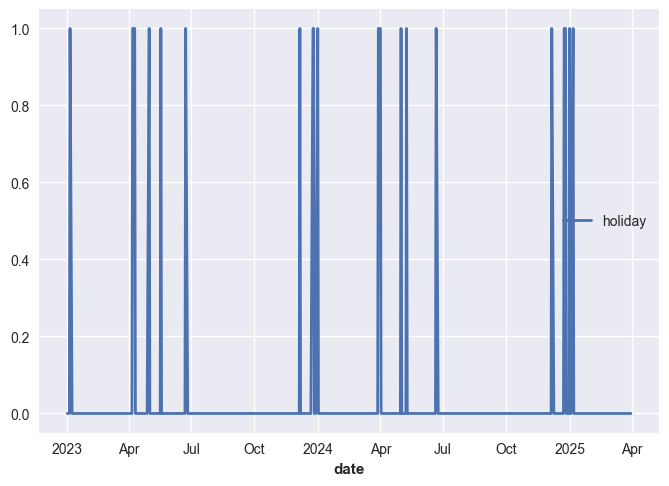

In [15]:
series_holiday = (
    TimeSeries
    .from_dataframe(
        df=cov_holiday.to_pandas(),
        time_col='date',
        freq='b',
        fill_missing_dates = False,
        value_cols='holiday'
    )
    # .astype(np.float32)
)
series_holiday.plot()

In [16]:
CUTOFF_DATE = pd.to_datetime("2025-01-01")
series_train, series_test = series.astype(np.float32).split_before(CUTOFF_DATE)

series_cov = (
    series_exam
    .concatenate(series_holiday, axis=1)
    .astype(np.float32)
)



# Plot
# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111)

# Scaler(MinMaxScaler(feature_range=(0, 1))).fit_transform(series).plot(ax=ax, label='pos')
# series_cov.plot(ax=ax)

# Train

<Axes: xlabel='date'>

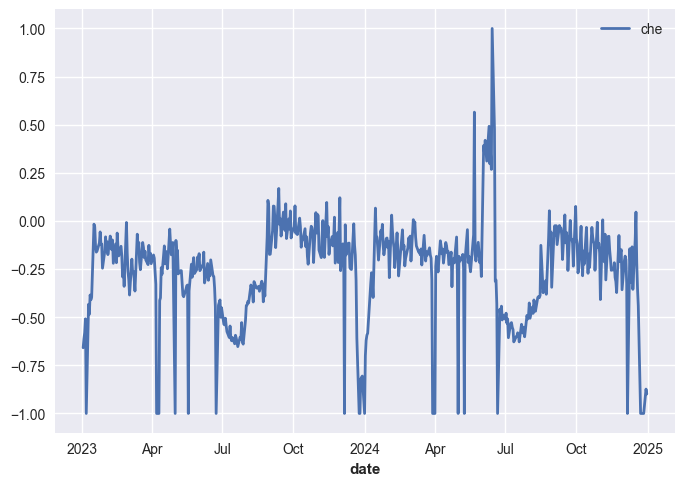

In [17]:
# transformer = Diff(1, dropna=True)
# series_transformed = transformer.fit_transform(series)
# series_train_diff = series_transformed.drop_after(CUTOFF_DATE)


series_train_transformed = series_train
# series_train_transformed = series_train_diff

transformer_target = Scaler(MinMaxScaler(feature_range=(-1, 1)))
# transformer_target = BoxCox(lmbda=0.)
series_train_transformed = transformer_target.fit_transform(series_train_transformed)


series_train_transformed.plot()

## ML and statistical models

In [18]:
version = datetime.datetime.now().strftime("%m-%d_%H-%M-%S")
model_name = "catboost"

input_chunk_length = 40
output_chunk_length = 30
num_epochs = 500


# Define params
add_encoders = {
    "datetime_attribute": {
        "future": ["dayofweek", 'day', 'month'],
        "past": ["dayofweek", 'day', 'month']
    },
    'cyclic': {
        'past': ["dayofweek", 'day', 'month'],
        'future': ["dayofweek", 'day', 'month']
    },
}

params_ml = {
    "lags": input_chunk_length,
    "lags_future_covariates": [0],
    "output_chunk_length": output_chunk_length,
    "add_encoders": {**add_encoders}
}
params_dl = {
    "input_chunk_length": input_chunk_length,
    "output_chunk_length": output_chunk_length,
    "add_encoders": {**add_encoders},  
    "n_epochs": num_epochs,
    "pl_trainer_kwargs": {
        "callbacks": [TQDMProgressBar(refresh_rate=4)],
        "logger": [
            TensorBoardLogger("logs/tensorboard", name=f"{model_name}-{restaurant}", version=version, default_hp_metric=False)
        ],
        'precision': "32-true",
    },
    "optimizer_kwargs": {
        'lr': 5e-4
    }
}

# Define models
match model_name:
    # =================================================
    # ML models
    # =================================================
    case "catboost":
        model = CatBoostModel(**params_ml)
        model.fit(
            series_train_transformed,
            future_covariates=series_cov,
        )
    case "xgboost":
        model = XGBModel(**params_ml)
        model.fit(
            series_train_transformed,
            future_covariates=series_cov,
        )
    case "lightbgm":
        model = LightGBMModel(**params_ml)
        model.fit(
            series_train_transformed,
            future_covariates=series_cov,
        )

    # =================================================
    # DL models
    # =================================================
    case 'rnn':
        params_dl['model'] = 'LSTM'

        model = RNNModel(**params_dl)
        model.fit(
            series_train_transformed,
            future_covariates=series_cov,
        )
    case "tsmixer":
        model = TSMixerModel(**params_dl)
        model.fit(
            series_train_transformed,
            future_covariates=series_cov,
        )
    case "transformer":
        model = TransformerModel(**params_dl)
        model.fit(
            series_train_transformed,
            past_covariates=series_cov.split_before(CUTOFF_DATE)[0],
        )
    case "tft":
        params_dl["categorical_embedding_sizes"] = {
            "holiday": (2, 2),
            "exam": (2, 2),
            "restaurant": (4, 4)
        }

        model = TFTModel(**params_dl)
        model.fit(
            series_train_transformed,
            future_covariates=series_cov,
        )
    case "n-beats":
        model = NBEATSModel(**params_dl)
        model.fit(
            series_train_transformed,
            past_covariates=series_cov.split_before(CUTOFF_DATE)[0],
        )
    
    case _:
        raise NotImplementedError()

Specified past encoders in `add_encoders` at model creation but model does not accept past covariates. past encoders will be ignored.


### Test

Text(0.5, 1.0, 'che | mape = 19.67%')

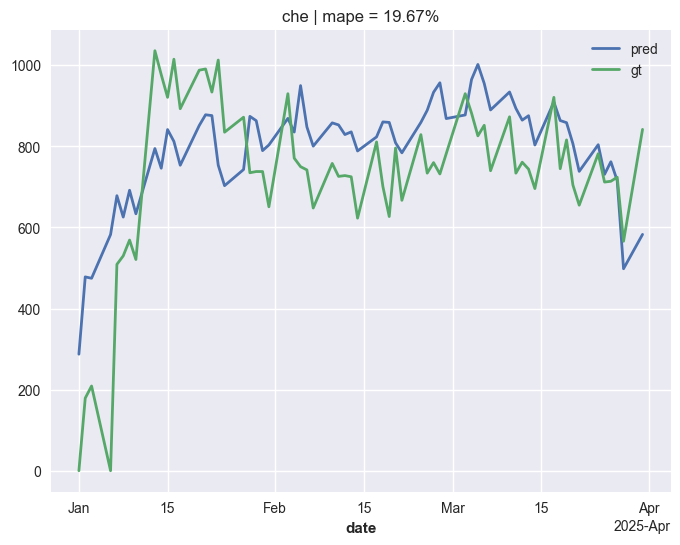

In [34]:
match model_name:
    # =================================================
    # ML models
    # =================================================
    case "catboost":
        series_pred = model.predict(
            n=len(series_test),
            future_covariates=series_cov
        )
    case "xgboost":
        series_pred = model.predict(
            n=len(series_test),
            future_covariates=series_cov
        )
    case "lightbgm":
        series_pred = model.predict(
            n=len(series_test),
            future_covariates=series_cov
        )

    # =================================================
    # DL models
    # =================================================
    case "rnn":
        series_pred = model.predict(
            n=len(series_test),
            future_covariates=series_cov
        )
    case "tsmixer":
        series_pred = model.predict(
            n=len(series_test),
            future_covariates=series_cov
        )
    case "transformer":
        series_pred = model.predict(
            n=len(series_test),
            past_covariates=series_cov
        )
    case "transformer":
        series_pred = model.predict(
            n=len(series_test),
            past_covariates=series_cov
        )
    case "tft":
        series_pred = model.predict(
            n=len(series_test),
            future_covariates=series_cov
        )
    case "n-beats":
        series_pred = model.predict(
            n=len(series_test),
            past_covariates=series_cov
        )

    case _:
        raise NotImplementedError()
    

series_pred = transformer_target.inverse_transform(series_pred)
# series_pred = transformer.inverse_transform(series_train_diff.concatenate(series_pred)).drop_before(CUTOFF_DATE)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
series_pred.plot(ax=ax, label='pred')
series_test.plot(ax=ax, label='gt')
# rmse_val = mape(series_test[comp], series_pred[comp])

df = pd.concat(
    [
        series_test.to_dataframe().rename(columns={restaurant: "gt"}),
        series_pred.to_dataframe().rename(columns={restaurant: "pred"})
    ],
    axis=1
)
df = df[df['gt'] > EPS]
mape_val = mean_absolute_percentage_error(df['gt'], df['pred'])

ax.set_title(f"{restaurant} | mape = {mape_val*100:.4}%")

# Train with entire data and forecast

In [41]:
transformer_target = Scaler(MinMaxScaler(feature_range=(-1, 1)))
series_transformed = transformer_target.fit_transform(series)

model = CatBoostModel(**params_ml)
model.fit(
    series_transformed,
    future_covariates=series_cov,
)

Specified past encoders in `add_encoders` at model creation but model does not accept past covariates. past encoders will be ignored.


CatBoostModel(lags=10, lags_past_covariates=None, lags_future_covariates=[0], output_chunk_length=1, output_chunk_shift=0, add_encoders={'datetime_attribute': {'future': ['dayofweek', 'day', 'month'], 'past': ['dayofweek', 'day', 'month']}, 'cyclic': {'past': ['dayofweek', 'day', 'month'], 'future': ['dayofweek', 'day', 'month']}}, likelihood=None, quantiles=None, random_state=None, multi_models=True, use_static_covariates=True, categorical_past_covariates=None, categorical_future_covariates=None, categorical_static_covariates=None)

## Backtest

`enable_optimization=True` is ignored because `retrain` is not `False` or `0`. To hide this warning, set `show_warnings=False` or `enable_optimization=False`.
Specified past encoders in `add_encoders` at model creation but model does not accept past covariates. past encoders will be ignored.
Specified past encoders in `add_encoders` at model creation but model does not accept past covariates. past encoders will be ignored.
Specified past encoders in `add_encoders` at model creation but model does not accept past covariates. past encoders will be ignored.
Specified past encoders in `add_encoders` at model creation but model does not accept past covariates. past encoders will be ignored.
Specified past encoders in `add_encoders` at model creation but model does not accept past covariates. past encoders will be ignored.
Specified past encoders in `add_encoders` at model creation but model does not accept past covariates. past encoders will be ignored.
Specified past encoders in `add_encod

<Axes: xlabel='time'>

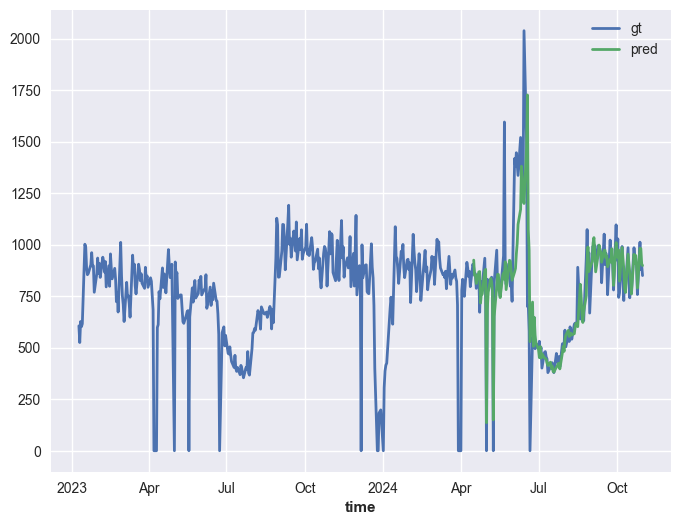

In [42]:
result = model.historical_forecasts(series_transformed, start=.7, future_covariates=series_cov, forecast_horizon=output_chunk_length)
result = transformer_target.inverse_transform(result)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

series.plot(ax=ax, label='gt')
result.plot(ax=ax, label='pred')

## Forecast and save

In [ ]:
N = 107
series_pred = model.predict(n=N, future_covariates=series_cov)
series_pred = transformer_target.inverse_transform(series_pred)


series_pred.to_dataframe().to_excel("data/inter/evaluation/exactum_Apr1.xlsx")